In [3]:
import numpy as np
import pandas as pd

In [4]:
def dist(vector1: list, vector2: list) -> float:
    """
    This method will calculate the euclidean distance between two data points.
    
    :param: 
        vector1 - numerical list
        vector2 - numerical list

    :returns:
       the distance betwen two vectors (float)
    """
    return np.linalg.norm(np.array(vector1) - np.array(vector2))

In [5]:
def edge_cluster(cluster, window):
    deviation = dist(cluster['mean'], window['mean']) > (dist(cluster['low'], cluster['mean']) + dist(window['mean'], window['high']))
    # D(m_i, m_w) > (D(l_i, m_i) + D(m_w, h_w))
    matching = (dist(cluster['mean'], window['mean']) < dist(cluster['low'], cluster['mean'])) and (dist(cluster['mean'], window['mean']) < dist(window['mean'], window['high']))
    # (D(m_i, m_w) < D(l_i, m_i)) and (D(m_i, m_w) < D(m_w, h_w))
    merging = (dist(cluster['low'], cluster['mean']) >= dist(cluster['mean'], window['mean'])) or (dist(cluster['mean'], window['mean']) <= dist(window['mean'], window['high']))
    # (D(l_i, m_i) >= D(m_i, m_w)) or (D(m_i, m_w) <= D(m_w, h_w))
    new_cluster = (dist(cluster['low'], cluster['mean']) < dist(cluster['mean'], window['mean'])) and (dist(cluster['mean'], window['mean']) > dist(window['mean'], window['high']))
    # (D(l_i, m_i) < D(m_i, m_w)) and (D(m_i, m_w) > D(m_w, h_w))
    return deviation, matching, merging, new_cluster

Stream 0 segment 1 size 3

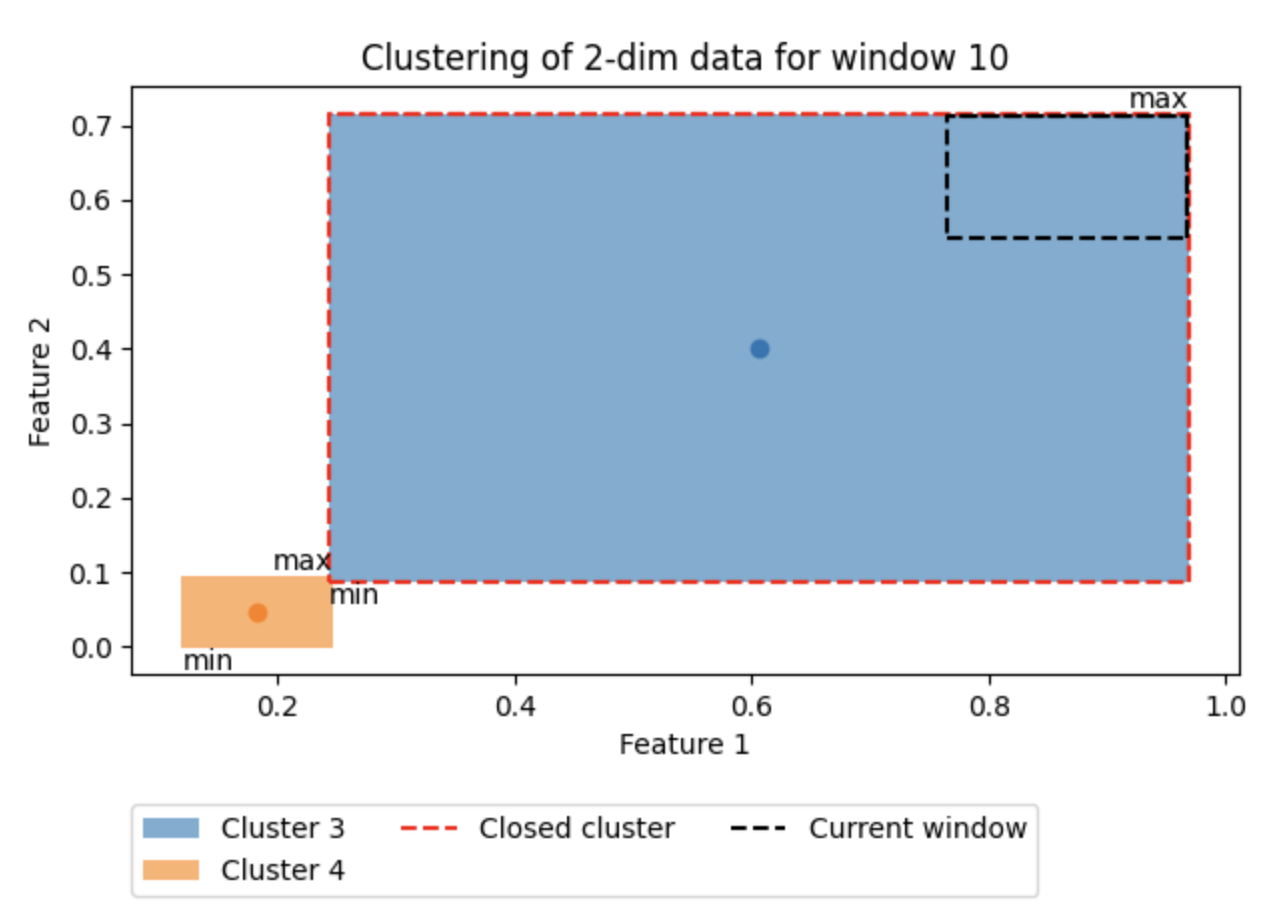

In [6]:
cluster = {
    "high": [0.96867268, 0.71623511],
    "mean": [0.60587082, 0.40125605],
    "low": [0.24306896, 0.08627698],
}

window = {
    "high": [0.9666365,  0.71177258],
    "mean": [0.86542274, 0.63046239],
    "low": [0.76420898, 0.54915221],
}

In [7]:
deviation, matching, merging, new_cluster = edge_cluster(cluster, window)

In [8]:
print("deviation", deviation) 
print("matching", matching)
print("merging", merging) 
print("form a new cluster", new_cluster)

deviation False
matching False
merging True
form a new cluster False


In [9]:
def recalculate_window_params(c: dict, w: dict) -> dict:
    """
    Recalculating the window low, high value vectors of c.

    :param: c - a dict with keys: high, low, and mean.
    :param: w - a dict with keys: high, low, and mean.

    :returns: c - with new values for high, low and mean.
    """
    
    lows_df = pd.DataFrame([c['low'], w['low']])
    highs_df = pd.DataFrame([c['high'], w['high']])

    highs = highs_df.max()
    lows = lows_df.min()
    means = (highs + lows) / 2

    return {
        "high": np.array(highs), 
        "low": np.array(lows),
        "mean": np.array(means),
        "cluster": c['cluster'],
    }

In [10]:
j = {
    "high": [0.24717815, 0.09366411],
    "mean": [0.18308194, 0.04625368],
    "low": [ 0.11898573, -0.00115675],
    "cluster": 4
}

cluster = {
    "high": [0.96867268, 0.71623511],
    "mean": [0.60587082, 0.40125605],
    "low": [0.24306896, 0.08627698],
    "cluster": 3
}

window = {
    "high": [0.9666365,  0.71177258],
    "mean": [0.86542274, 0.63046239],
    "low": [0.76420898, 0.54915221]
}

cluster = recalculate_window_params(cluster, window)
print(cluster)
cluster['cluster'] != j['cluster'] and ((dist(cluster['low'], j['mean']) >= dist(cluster['mean'], j['mean'])) or (dist(cluster['mean'], j['high']) <= dist(j['mean'], j['high'])))

{'high': array([0.96867268, 0.71623511]), 'low': array([0.24306896, 0.08627698]), 'mean': array([0.60587082, 0.40125605]), 'cluster': 3}


False

In [24]:
print(dist(cluster['low'], j['mean']) >= dist(cluster['mean'], j['mean']))
print((dist(cluster['mean'], j['mean']) <= dist(j['mean'], j['high'])))

True
True


Stream 0 segment 1 size 3

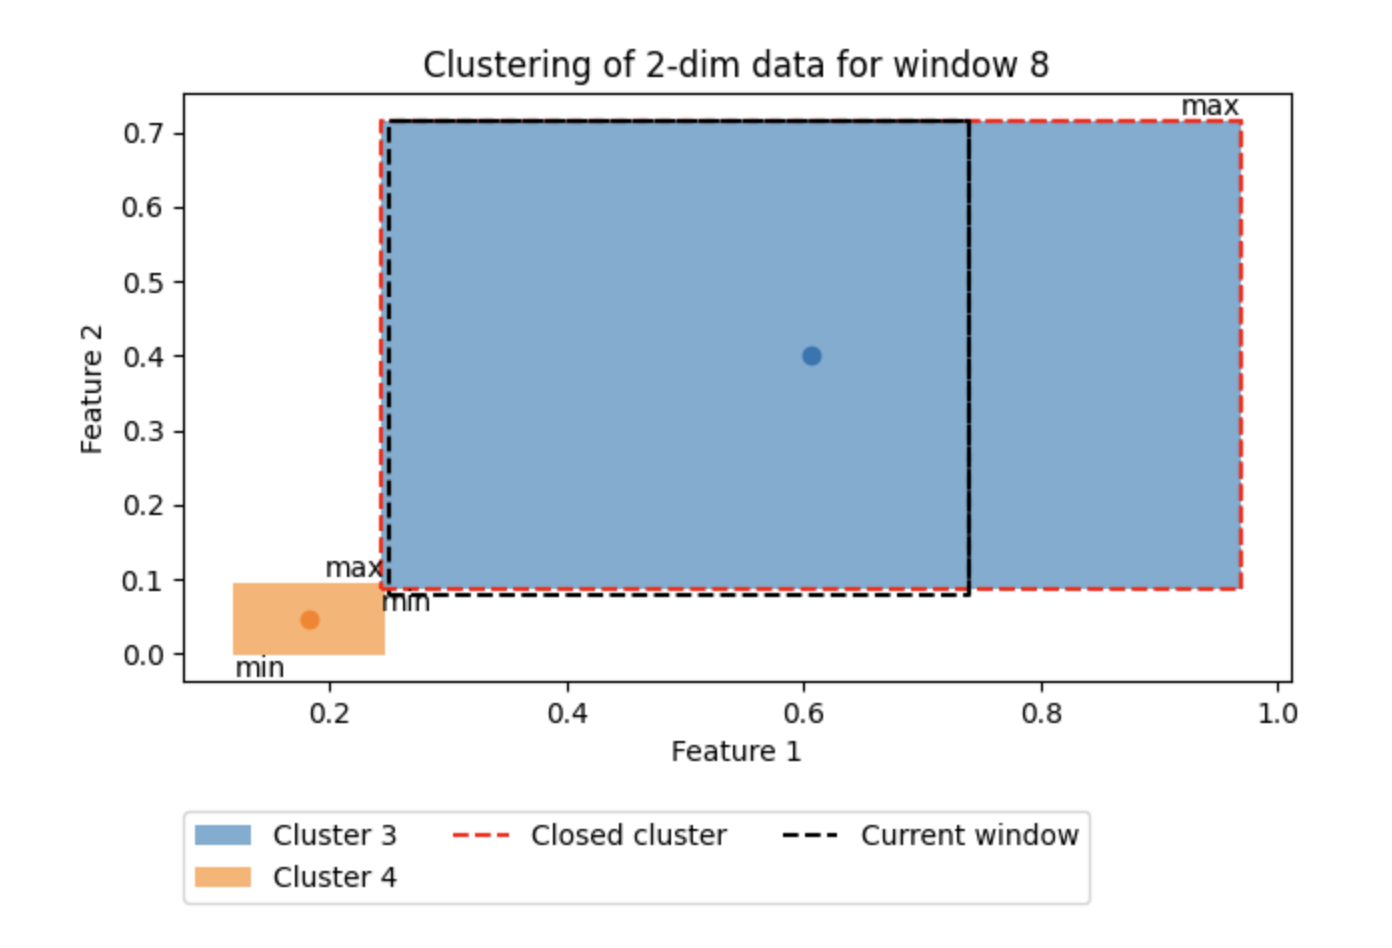
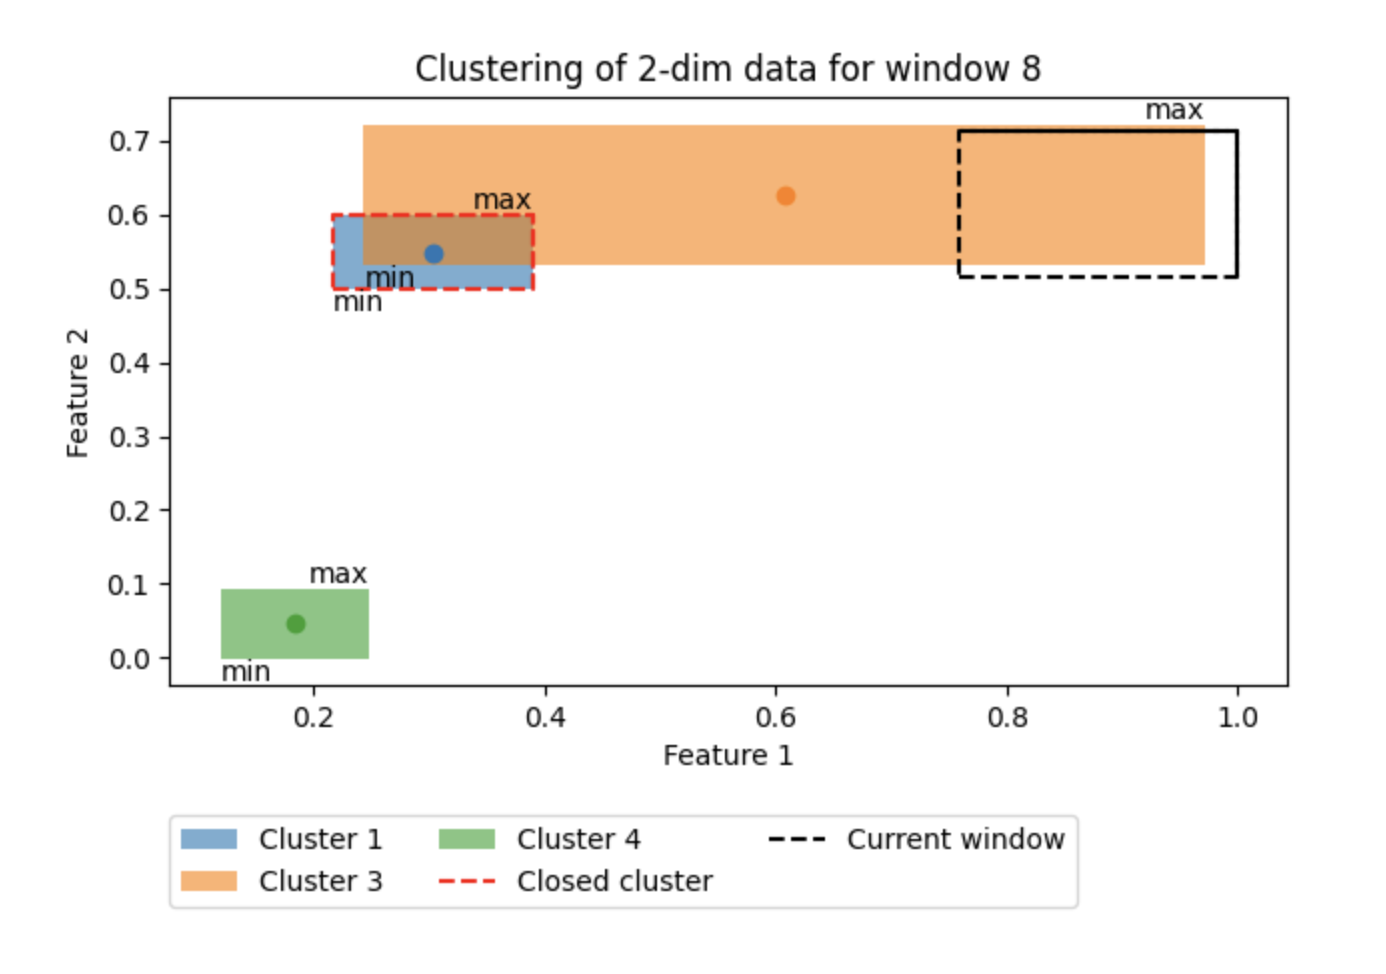

In [12]:
cluster = {
    "high": [0.96867268, 0.71623511],
    "mean": [0.60587082, 0.40125605],
    "low": [0.24306896, 0.08627698],
}

window = {
    "high": [0.73898646, 0.71581697],
    "mean": [0.49441179, 0.3969808 ],
    "low": [0.24983711, 0.07814462],
}

In [13]:
deviation, matching, merging, new_cluster = edge_cluster(cluster, window)

In [14]:
print("deviation", deviation) 
print("matching", matching)
print("merging", merging) 
print("form a new cluster", new_cluster)

deviation False
matching True
merging True
form a new cluster False


Stream 1 segment 1 size 3

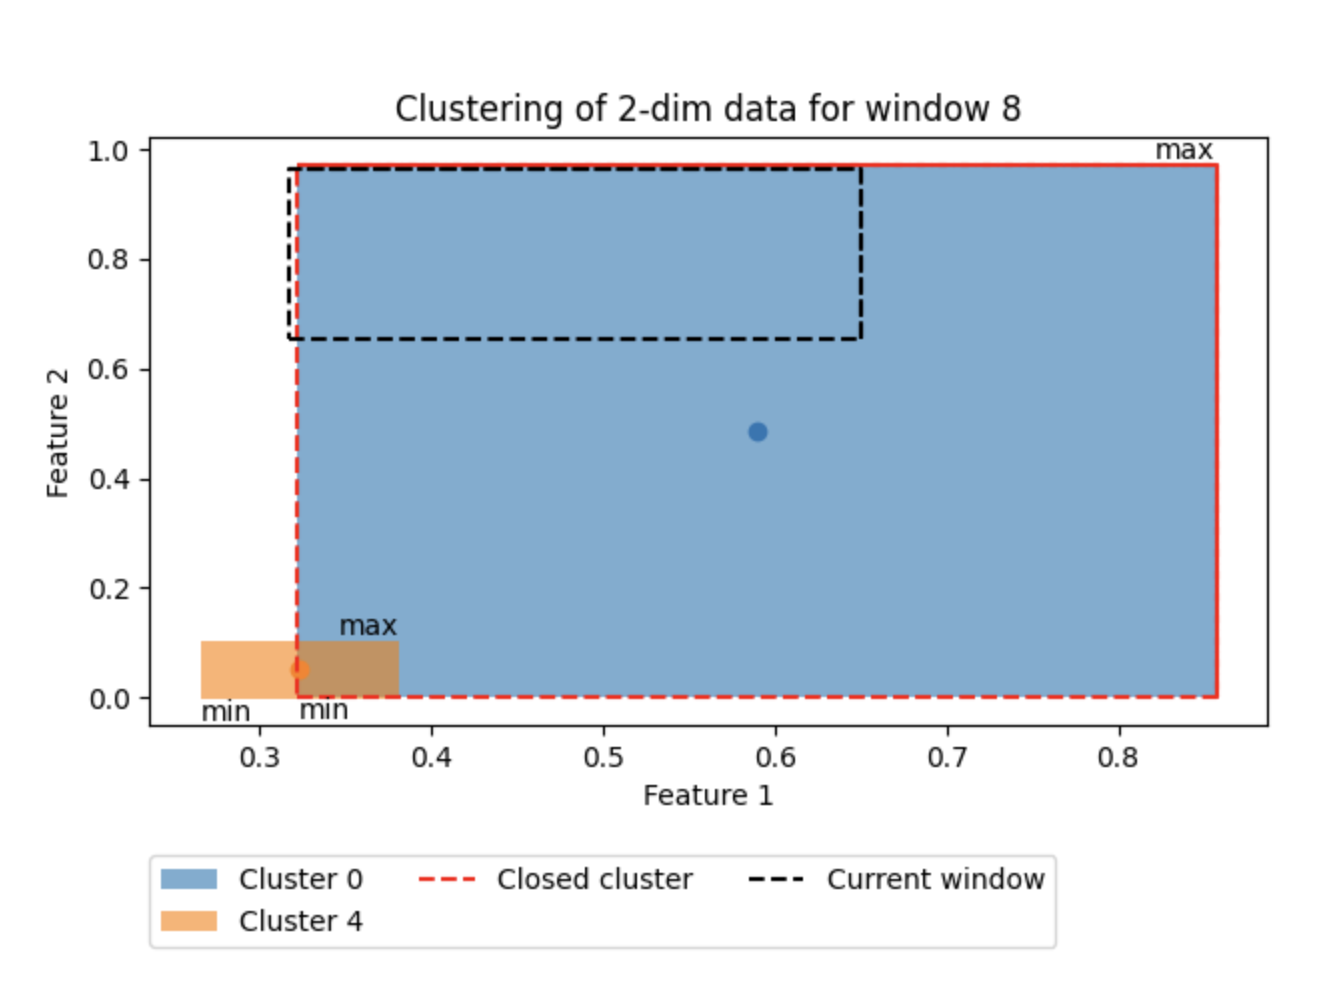

In [15]:
cluster = {
    "high": [0.85715388, 0.97202867],
    "mean": [0.58968742, 0.48634432],
    "low": [0.32222096, 0.00065997],
    "cluster": 0
}

window = {
    "high": [0.65079134, 0.96249346],
    "mean": [0.48405191, 0.80778875],
    "low": [0.31731248, 0.65308404],
}

j = {
    "high": [0.38078076, 0.10387155],
    "mean": [0.32305672, 0.0510285 ],
    "low": [ 0.26533267, -0.00181455],
    "cluster": 4
}

In [16]:
deviation, matching, merging, new_cluster = edge_cluster(cluster, window)

cluster = recalculate_window_params(cluster, window)
print(cluster)

cluster['cluster'] != j['cluster'] and ((dist(cluster['low'], j['mean']) >= dist(cluster['mean'], j['mean'])) or (dist(cluster['mean'], j['high']) <= dist(j['mean'], j['high'])))

{'high': array([0.85715388, 0.97202867]), 'low': array([0.31731248, 0.00065997]), 'mean': array([0.58723318, 0.48634432]), 'cluster': 0}


False

In [17]:
print("deviation", deviation) 
print("matching", matching)
print("merging", merging) 
print("form a new cluster", new_cluster)

deviation False
matching False
merging True
form a new cluster False


Stream 0 segment 1 size 5

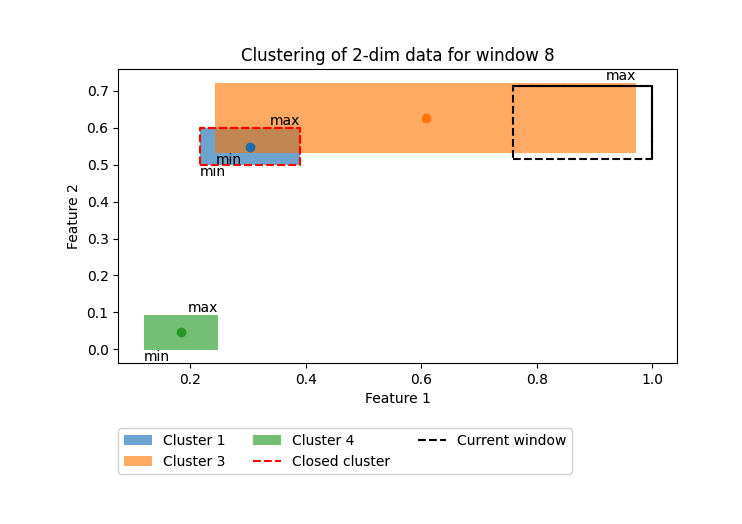

In [18]:
cluster = {
    "high": [0.39029833, 0.59833918],
    "mean": [0.30342303, 0.54862778],
    "low": [0.21654772, 0.49891637],
    "cluster": 1
}

window = {
    "high": [0.99891212, 0.71477947],
    "mean": [0.87901177, 0.61542624],
    "low": [0.75911142, 0.516073  ],
}

j = {
    "high": [0.97173226, 0.7224287 ],
    "mean": [0.60740061, 0.62736944],
    "low": [0.24306896, 0.53231018],
    "cluster": 3
}

k = {
    "high": [0.24717815, 0.09366411],
    "mean": [0.18308194, 0.04625368],
    "low": [ 0.11898573, -0.00115675],
    "cluster": 4
}

In [19]:
from sklearn.metrics import pairwise_distances_argmin
# print([np.ndarray([0.87901177, 0.61542624])])
clusters = np.array([[0.30342303, 0.54862778], [0.60740061, 0.62736944], [0.18308194, 0.04625368]])

print(pairwise_distances_argmin([np.array([0.87901177, 0.61542624])], clusters))

[1]


In [20]:
deviation, matching, merging, new_cluster = edge_cluster({
    "high": [0.97173226, 0.7224287 ],
    "mean": [0.60740061, 0.62736944],
    "low": [0.24306896, 0.53231018],
    "cluster": 3
}
, window)

# cluster = recalculate_window_params(cluster, window)
# print(cluster)

# cluster['cluster'] != j['cluster'] and ((dist(cluster['low'], j['mean']) >= dist(cluster['mean'], j['mean'])) or (dist(cluster['mean'], j['high']) <= dist(j['mean'], j['high'])))
# cluster['cluster'] != k['cluster'] and ((dist(cluster['low'], j['mean']) >= dist(cluster['mean'], k['mean'])) or (dist(cluster['mean'], k['high']) <= dist(k['mean'], k['high'])))

In [21]:
print("deviation", deviation) 
print("matching", matching)
print("merging", merging) 
print("form a new cluster", new_cluster)

deviation False
matching False
merging True
form a new cluster False


In [22]:
def find_the_closest_cluster(w: dict, C: list) -> dict:
    """
    Find the closest cluster to the window w.

    :param: w - a data window
    :param: C - list of Clusters

    :return: the closest cluster
    """
    results = []
    for c in C:
        results.append({
            "dist": dist(w['mean'], c['mean']),
            "cluster": c
        })
    sorted_results = sorted(results, key=lambda x: x['dist'], reverse=False)
    print(sorted_results)
    min_dist = None
    if len(sorted_results) != 0:
        min_dist = sorted_results[0]['cluster']
        sorted_results.append({
            "window": w,
            "cluster": c,
            "dist": min_dist
        })
    
    return min_dist

In [23]:

find_the_closest_cluster(window, [cluster, j, k])

[{'dist': 0.271873614502742, 'cluster': {'high': [0.97173226, 0.7224287], 'mean': [0.60740061, 0.62736944], 'low': [0.24306896, 0.53231018], 'cluster': 3}}, {'dist': 0.5794518374059738, 'cluster': {'high': [0.39029833, 0.59833918], 'mean': [0.30342303, 0.54862778], 'low': [0.21654772, 0.49891637], 'cluster': 1}}, {'dist': 0.8990415626325529, 'cluster': {'high': [0.24717815, 0.09366411], 'mean': [0.18308194, 0.04625368], 'low': [0.11898573, -0.00115675], 'cluster': 4}}]


{'high': [0.97173226, 0.7224287],
 'mean': [0.60740061, 0.62736944],
 'low': [0.24306896, 0.53231018],
 'cluster': 3}